# Importing libraries📚

In [1]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
from torchvision.transforms import ToTensor
from torchvision.utils import make_grid
from torch.utils.data.dataloader import DataLoader
from torch.utils.data import random_split
import pandas as pd
import seaborn as sns
from colorama import Fore, Back, Style
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

# Getting data 💽

In [2]:
train = pd.read_csv("../input/titanic/train.csv")
test = pd.read_csv("../input/titanic/test.csv")
submission = pd.read_csv("../input/titanic/gender_submission.csv")

In [3]:
train.shape

(891, 12)

In [4]:
test.shape

(418, 11)

In [5]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [7]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# EDA 📊

In [8]:
red = Fore.RED
grn = Fore.GREEN
blu = Fore.BLUE
ylw = Fore.YELLOW
wht = Fore.WHITE

In [9]:
def plot_distribution(feature,color):
    plt.figure(dpi=125)
    sns.distplot(train[feature],color=color);
    print("{}Max value of {} is {}\n{}Min value of {} is {}\n{}Mean value of {} is {}\n{}Std value of {} is {}\n{}Median value of {} is {}".format(red,feature,train[feature].max(),blu,feature,train[feature].min(),grn,feature,train[feature].mean(),ylw,feature,train[feature].std(),wht,feature,train[feature].median()));

Max value of Age is 80.0
Min value of Age is 0.42
Mean value of Age is 29.69911764705882
Std value of Age is 14.526497332334044
Median value of Age is 28.0


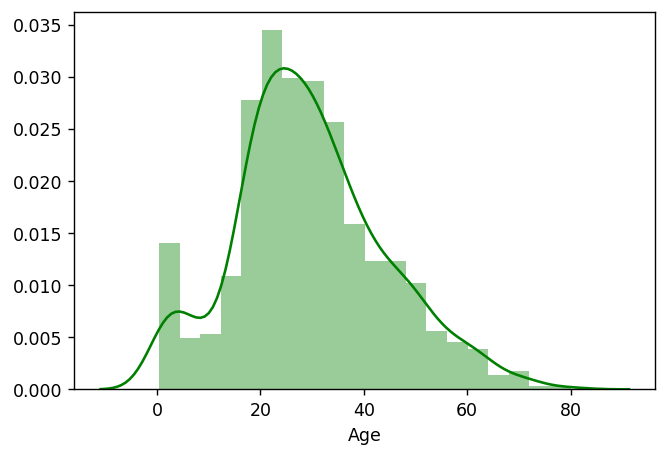

In [10]:
plot_distribution('Age','green')

As we know from the disaster.. women and children were the first to be evacuated.. mean age is 29.6, median age is 28.. both of which are >18 which suggests the people with missing ages are adults ... standard deviation is 14.5 which is <18 which suggests they are chilren..

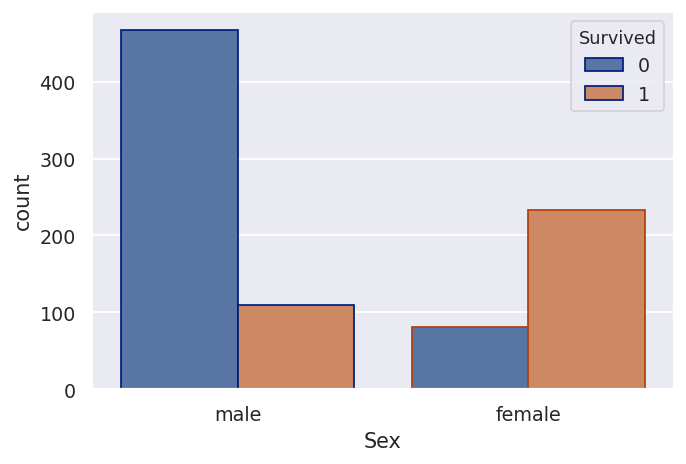

In [11]:
sns.set(style = 'darkgrid')
plt.figure(dpi=125)
sns.countplot(x=train.Sex, hue=train.Survived, data=train,edgecolor = sns.color_palette('dark',2));

As we can confirm females had a greater survival rate compared to males.

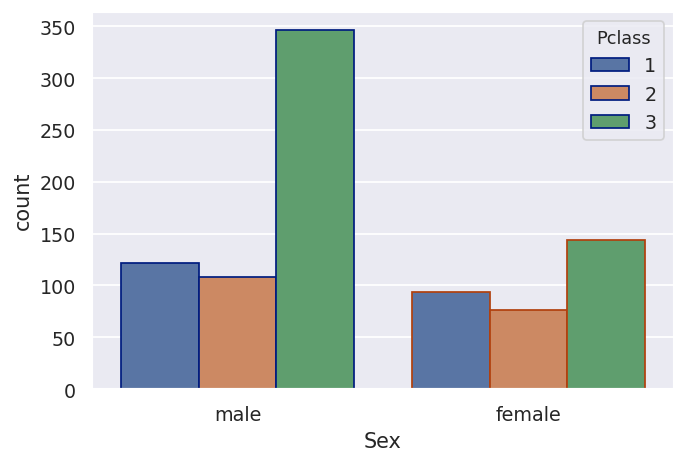

In [12]:
plt.figure(dpi=125)
sns.countplot(x = train.Sex, hue = train.Pclass,data = train,edgecolor = sns.color_palette('dark',3));

There were many people from both genders in 3rd class(as expected)... the second most filled class was 1st class ... this maybe suggests huge price difference between classes.. not sure though 🤷‍♂️🤷‍♂️

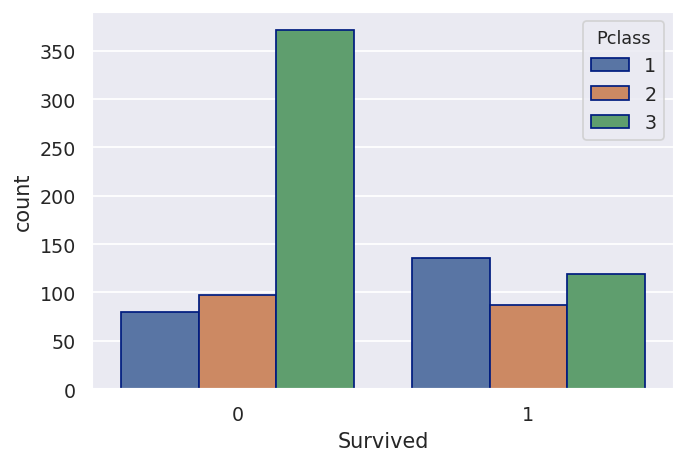

In [13]:
plt.figure(dpi=125)
sns.countplot(x = train.Survived, hue = train.Pclass, data = train,edgecolor = sns.color_palette('dark',1));

Most people survived were from 1st class.. so people in 1st class had a greater chance of survival

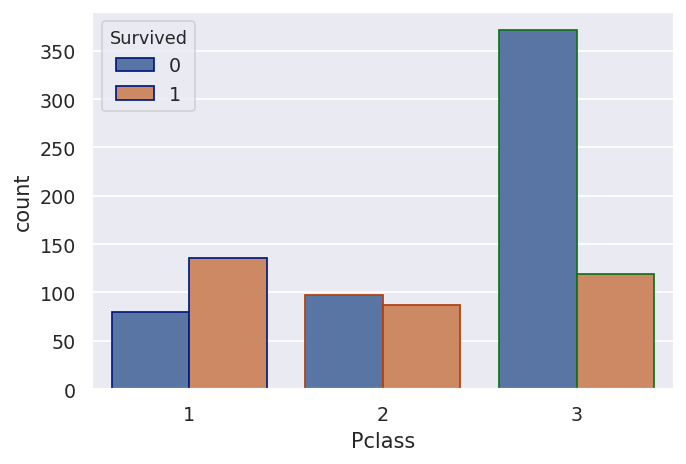

In [14]:
plt.figure(dpi=125)
sns.countplot(x = train.Pclass, hue = train.Survived, data = train,edgecolor = sns.color_palette('dark',5));

Only people from 1st class had a greater survival rate compared to classes 2 and 3... maybe there were fewer people in 1st class

In [15]:
train.groupby('Pclass').Survived.value_counts()

Pclass  Survived
1       1           136
        0            80
2       0            97
        1            87
3       0           372
        1           119
Name: Survived, dtype: int64

Well there weren't fewer people in 1st class.. so we can conclude that people in first class did indeed had a higher chance and rate of survival

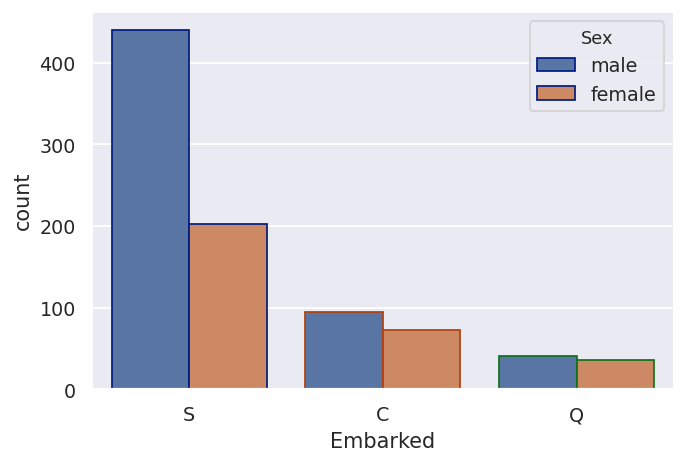

In [16]:
plt.figure(dpi=125)
sns.countplot(x = train.Embarked, hue = train.Sex, data = train,edgecolor = sns.color_palette('dark',6));

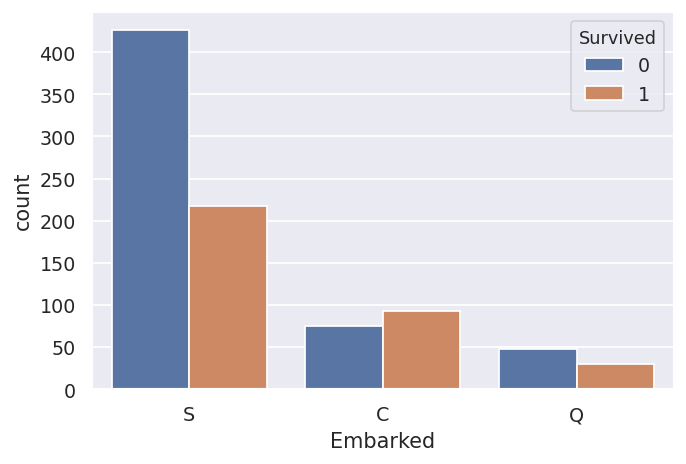

In [17]:
plt.figure(dpi=125)
sns.countplot(x = train.Embarked, hue = train.Survived, data = train);

More people survived from Cherbourg compared to other two

### Name

In [18]:
train['Name'] = train.Name.str.extract('([A-Za-z]+)\.',expand = False)

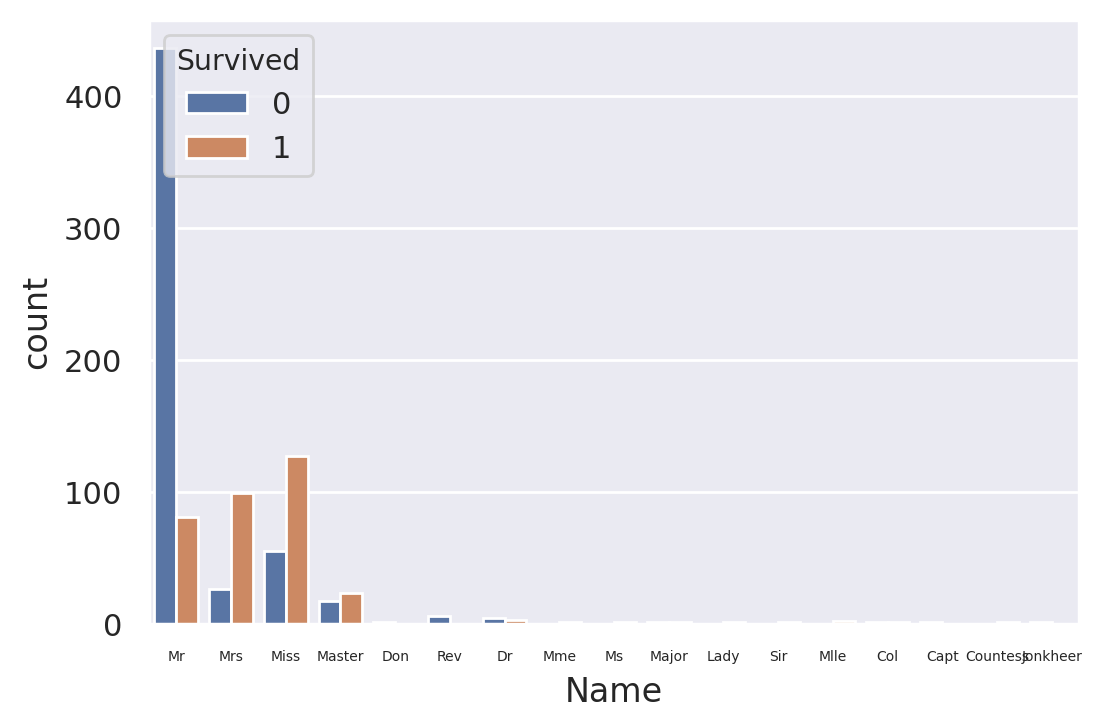

In [19]:
plt.figure(dpi=200)
plt.xticks(size=5)
sns.countplot(x = train.Name, hue = train.Survived, data = train);

In [20]:
top6 = train['Name'].value_counts()[:6].index.to_list()
top6

['Mr', 'Miss', 'Mrs', 'Master', 'Dr', 'Rev']

In [21]:
train['Name'] = train['Name'].apply(lambda x: x if x in top6 else 'Other')

In [22]:
train.groupby('Name').Survived.value_counts()

Name    Survived
Dr      0             4
        1             3
Master  1            23
        0            17
Miss    1           127
        0            55
Mr      0           436
        1            81
Mrs     1            99
        0            26
Other   1             9
        0             5
Rev     0             6
Name: Survived, dtype: int64

### Family

In [23]:
train['family'] = train['SibSp'] + train['Parch'] + 1

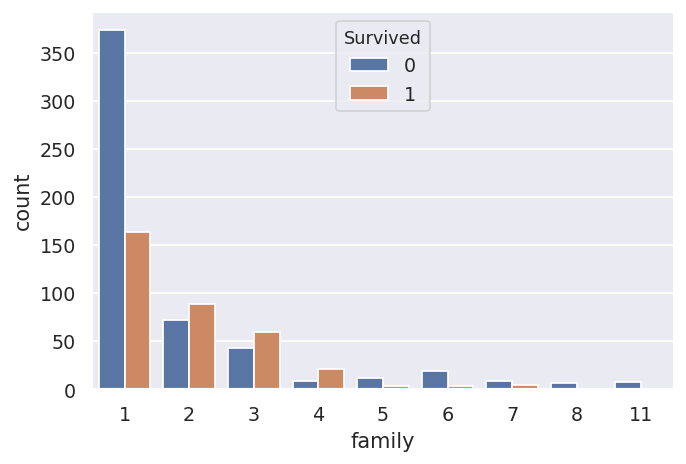

In [24]:
plt.figure(dpi=125)
sns.countplot(x = train.family, hue = train.Survived, data = train);

In [25]:
train.groupby('family').Survived.value_counts()

family  Survived
1       0           374
        1           163
2       1            89
        0            72
3       1            59
        0            43
4       1            21
        0             8
5       0            12
        1             3
6       0            19
        1             3
7       0             8
        1             4
8       0             6
11      0             7
Name: Survived, dtype: int64

This seems kinda random .. only people with family member size of 2,3,4 survived greater than the rest 🤔🤔.

In [26]:
for i in range(len(train)):
    if(train['family'][i] > 1):
        train['family'][i] = 1
    else:
        train['family'][i] = 0

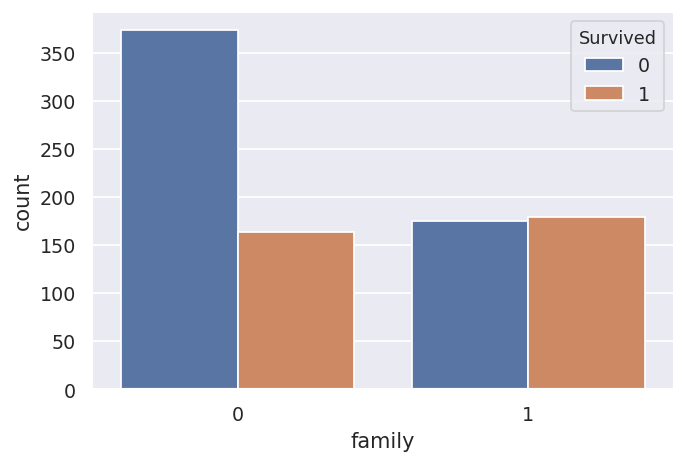

In [27]:
plt.figure(dpi=125)
sns.countplot(x = train.family, hue = train.Survived, data = train);

people with family had greater rate of survival

### Cabin

In [28]:
train.groupby('Cabin').Survived.value_counts()

Cabin  Survived
A10    0           1
A14    0           1
A16    1           1
A19    0           1
A20    1           1
                  ..
F38    0           1
F4     1           2
G6     0           2
       1           2
T      0           1
Name: Survived, Length: 163, dtype: int64

In [29]:
train['Cabin'].fillna('S',inplace=True)

In [30]:
for i in range(len(train)):
    train['Cabin'][i] = train['Cabin'][i][0]

In [31]:
train.groupby('Cabin').Survived.value_counts()

Cabin  Survived
A      0             8
       1             7
B      1            35
       0            12
C      1            35
       0            24
D      1            25
       0             8
E      1            24
       0             8
F      1             8
       0             5
G      0             2
       1             2
S      0           481
       1           206
T      0             1
Name: Survived, dtype: int64

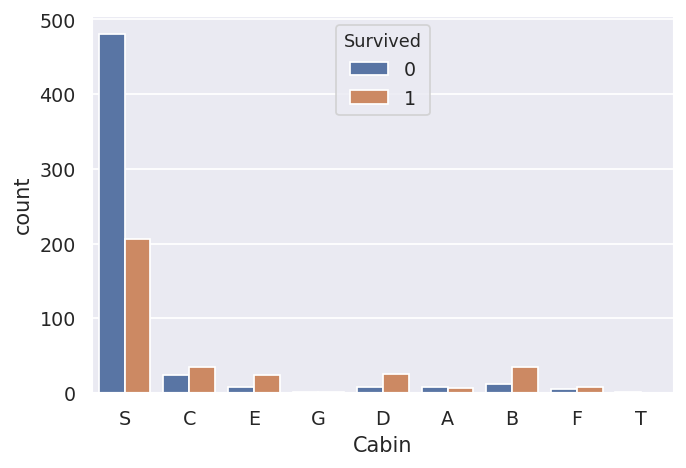

In [32]:
plt.figure(dpi = 125)
sns.countplot(x = train.Cabin,hue = train.Survived, data = train);

people from cabins were more likely to survive

### Fare

Max value of Fare is 512.3292
Min value of Fare is 0.0
Mean value of Fare is 32.2042079685746
Std value of Fare is 49.693428597180905
Median value of Fare is 14.4542


<Figure size 750x500 with 0 Axes>

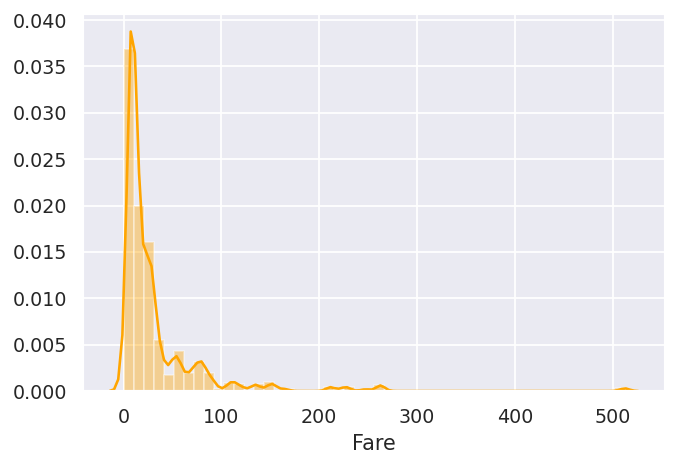

In [33]:
plt.figure(dpi=125)
plot_distribution('Fare','orange')

The minimum fare is 0.0 which means there was/were someone/some people with a free ride in titanic(probably in 1st class) 😅😅

In [34]:
train['fare_val'] = 0
for i in range(len(train)):
    if(train['Fare'][i] > 32.0):
        train['fare_val'][i] = 1

In [35]:
train.groupby('fare_val').Survived.value_counts()

fare_val  Survived
0         0           464
          1           216
1         1           126
          0            85
Name: Survived, dtype: int64

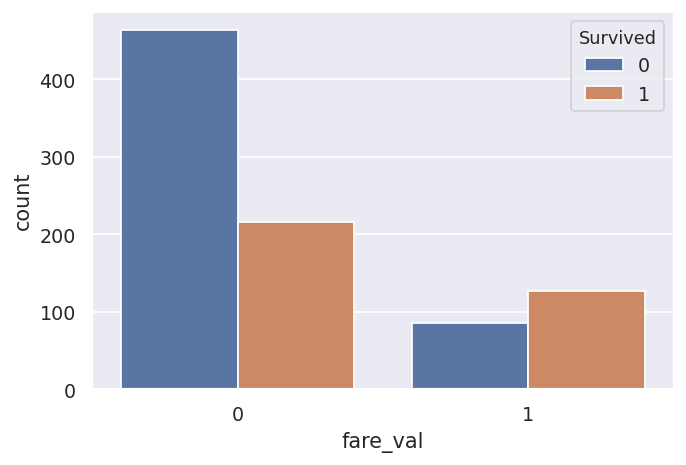

In [36]:
plt.figure(dpi=125)
sns.countplot(x = train.fare_val, hue = train.Survived, data = train);

People with greater fare had a higher rate of survival

#### Making same modifications to test dataset

In [37]:
#family
test['family'] = test['SibSp'] + test['Parch'] + 1
for i in range(len(test)):
    if(test['family'][i] > 1):
        test['family'][i] = 1
    else:
        test['family'][i] = 0

#Name
test['Name'] = test['Name'].apply(lambda x: x if x in top6 else 'Other')

#Cabin
test['Cabin'].fillna('S',inplace=True)

for i in range(len(test)):
    test['Cabin'][i] = test['Cabin'][i][0]


#Fare
test['fare_val'] = 0
for i in range(len(test)):
    if(test['Fare'][i] > 32.0):
        test['fare_val'][i] = 1

# Data Preprocessing 🗄️

In [38]:
features = [##'PassengerId',
            'Pclass',
            #'Name',
            'Sex',
            'Age',
            ##'SibSp',
            ##'Parch',
            'family',#derived from SibSp & Parch
            #'Ticket',
            ##'Fare',
            'fare_val',#derived from Fare
            #'Cabin',
            'Embarked'
           ]

target = 'Survived'

In [39]:
train[features].isnull().sum()

Pclass        0
Sex           0
Age         177
family        0
fare_val      0
Embarked      2
dtype: int64

In [40]:
test[features].isnull().sum()

Pclass       0
Sex          0
Age         86
family       0
fare_val     0
Embarked     0
dtype: int64

In [41]:
'''Age_mean = train['Age'].mean()
train['Age'] = train['Age'].fillna(value = Age_mean)

Age_mean_t = test['Age'].mean()
test['Age'] = test['Age'].fillna(value = Age_mean_t)
f"'train',{Age_mean}, 'test',{Age_mean_t}"''';

In [42]:
Age_std = train['Age'].std()
train['Age'] = train['Age'].fillna(value = Age_std)

Age_std_t = test['Age'].std()
test['Age'] = test['Age'].fillna(value = Age_std_t)
f"'train',{Age_std}, 'test',{Age_std_t}"

"'train',14.526497332334044, 'test',14.18120923562442"

In [43]:
from sklearn.preprocessing import LabelEncoder

lbl = LabelEncoder()

train['Sex'] = lbl.fit_transform(train[['Sex']].values.ravel())
test['Sex'] = lbl.fit_transform(test[['Sex']].values.ravel())

In [44]:
#lbl2 = LabelEncoder()
#train['Name'] = lbl2.fit_transform(train[['Name']].values.ravel())
#test['Name'] = lbl2.fit_transform(test[['Name']].values.ravel())

In [45]:
train['Embarked'] = train['Embarked'].fillna(value=train['Embarked'].mode()[0])
test['Embarked'] = test['Embarked'].fillna(value=test['Embarked'].mode()[0])


In [46]:
train_ds = train[features]
test_ds = test[features]

In [47]:
train_ds = pd.get_dummies(columns = ['Embarked','Pclass'],data=train_ds,drop_first = True)
test_ds = pd.get_dummies(columns = ['Embarked','Pclass'],data=test_ds,drop_first = True)

In [48]:
print(train_ds.head())
train_ds.shape

   Sex   Age  family  fare_val  Embarked_Q  Embarked_S  Pclass_2  Pclass_3
0    1  22.0       1         0           0           1         0         1
1    0  38.0       1         1           0           0         0         0
2    0  26.0       0         0           0           1         0         1
3    0  35.0       1         1           0           1         0         0
4    1  35.0       0         0           0           1         0         1


(891, 8)

In [49]:
print(test_ds.head())
test_ds.shape

   Sex   Age  family  fare_val  Embarked_Q  Embarked_S  Pclass_2  Pclass_3
0    1  34.5       0         0           1           0         0         1
1    0  47.0       1         0           0           1         0         1
2    1  62.0       0         0           1           0         1         0
3    1  27.0       0         0           0           1         0         1
4    0  22.0       1         0           0           1         0         1


(418, 8)

In [50]:
#train_ds.drop(columns = ['Cabin_T'],inplace = True)

# Creating a XGBoost Model with Randomized Search ❤️‍🔥

In [51]:
y_train = train[target]

In [52]:
from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(train_ds, y_train, test_size=0.30)

In [53]:
X_train.columns

Index(['Sex', 'Age', 'family', 'fare_val', 'Embarked_Q', 'Embarked_S',
       'Pclass_2', 'Pclass_3'],
      dtype='object')

In [54]:
from sklearn.model_selection import train_test_split,cross_val_score,RandomizedSearchCV,GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [55]:
'''rfc = RandomForestClassifier()

params = {'n_estimators': [200,500,800,1000,1200],
          'max_depth': [3,5,7],
          'criterion':['entropy', 'gini'],
          'min_samples_leaf' : [1, 2, 3, 4, 5],
          'max_features':['auto'],
          'min_samples_split': [3, 5, 10],
          'max_leaf_nodes':[2,3,5,7],
          }

rfc_cv = RandomizedSearchCV(rfc, params, cv = 250, n_jobs=-1, verbose=2).fit(X_train, y_train)''';

In [56]:
rfc = XGBClassifier()

params = {'n_estimators': [200,500,800,1000,1200],
          'max_depth': [3,5,7],
          'objective' : ['binary:logistic'],
          'min_samples_leaf' : [1, 2, 3, 4, 5],
          'max_leaf_nodes':[2,3,5,7],
          'min_child_weight': [1, 5, 10],
          'gamma': [0.5, 1, 1.5, 2, 5],
          }

rfc_cv = RandomizedSearchCV(rfc, params, cv = 10, n_jobs=-1, verbose=2).fit(X_train, y_train)

Fitting 10 folds for each of 10 candidates, totalling 100 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  33 tasks      | elapsed:    7.9s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   16.0s finished


In [57]:
rfc_cv.best_params_
best_model = rfc_cv.best_estimator_

print(best_model)
print(rfc_cv.best_score_)

XGBClassifier(gamma=1.5, max_depth=5, max_leaf_nodes=2, min_child_weight=5,
              min_samples_leaf=4, n_estimators=1200)
0.8072452636968765


In [58]:
rfc_pred = best_model.predict(X_valid)

print("Accuracy: ", accuracy_score(y_valid, rfc_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_valid, rfc_pred))

Accuracy:  0.8208955223880597

Confusion Matrix

[[157  20]
 [ 28  63]]


## Saving the Model 💾

In [59]:
import pickle

filename = 'Titanic_model.sav'
pickle.dump(best_model, open(filename, 'wb'))

## Loading the Model 🔃

In [60]:
loaded_model = pickle.load(open(filename, 'rb'))
result = loaded_model.score(X_valid, y_valid)
print(result)

0.8208955223880597


In [61]:
print(rfc_pred)

[0 1 1 1 0 0 1 1 1 0 1 0 0 1 1 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 0 1 0 0 0 0 1
 1 1 1 0 0 0 1 0 1 0 0 0 1 0 0 1 1 0 1 0 0 0 1 0 0 0 0 0 0 0 0 1 1 0 1 0 0
 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 1 1 0 0 1 1 1 0
 0 1 0 0 1 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 1 0 1 0 1 0 0 1 0 0 0 0 0 1 0 0
 0 0 0 1 0 0 1 0 1 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 1 0 0 0 0 0 0 0 1 1 0 1
 0 0 0 0 1 1 0 0 0 1 0 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 1 0 0 0 1 1 0
 0 0 1 0 0 0 1 0 0 0 0 0 1 0 1 1 0 0 0 1 0 1 0 1 0 0 0 0 1 0 0 0 1 0 0 1 1
 0 0 0 0 0 0 0 1 0]


In [62]:
passId = test[['PassengerId']].values

In [63]:
test_ds.head()

,Sex,Age,family,fare_val,Embarked_Q,Embarked_S,Pclass_2,Pclass_3
0,1,34.5,0,0,1,0,0,1
1,0,47.0,1,0,0,1,0,1
2,1,62.0,0,0,1,0,1,0
3,1,27.0,0,0,0,1,0,1
4,0,22.0,1,0,0,1,0,1


In [64]:
final_pred = best_model.predict(test_ds)

# My Submission 🙋‍♂️

In [65]:
sub = {'PassengerId':passId.ravel(), 'Survived':final_pred}

In [66]:
submission_csv = pd.DataFrame(sub)

In [67]:
submission_csv.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0


In [68]:
submission_csv.to_csv('final_sub_titanic_xgb_cv_10.csv',index = False)

In [69]:
x = pd.read_csv("./final_sub_titanic_xgb_cv_10.csv")

In [70]:
x.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0


## Checkout my other [**Notebook**](https://www.kaggle.com/mdhamani/titanic-getting-better-eda-pytorch-gpu-top-14) with PyTorch Neural Network Classifier

# To-Do📋
## Tuning parameters 🤷‍♂️🤷‍♂️
## Make the PyTorch Model more accurate